In [22]:
# ── DATA & MATH ──────────────────────────────────────────
import pandas as pd
import numpy as np

# ── VISUALIZATION ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── PREPROCESSING ─────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, GroupKFold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder, OrdinalEncoder

# ── REGRESSION MODELS ─────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
# Gradient boosting powerhouses (install if not present):
# pip install xgboost lightgbm catboost
import xgboost as xgb                          # XGBRegressor
from lightgbm import LGBMRegressor             # LightGBM
# from catboost import CatBoostRegressor       # CatBoost (optional)

# ── REGRESSION METRICS ────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── SETTINGS ──────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1.1 DATA INSPECTION

In [23]:
df = pd.read_csv('house_price_regression_dataset.csv')

df.head()           # first 5 rows
df.tail()           # last 5 rows
df.info()           # dtypes, non-null counts
df.describe()       # mean, std, min, max, quartiles
df.shape            # (rows, cols)
df.dtypes
df.nunique()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64

In [24]:
# # Check and remove duplicates
# df.drop_duplicates(inplace=True)

# # Missing values — how many and what % ?
# df.isnull().sum()
# df.isnull().sum() / len(df) * 100

# # Decision:
# # < 5% missing  → drop those rows
# # 5–30% missing → fill (mean for normal, median for skewed)
# # > 30% missing → drop the whole column

# df.dropna(inplace=True)                                  # drop rows
# df['col'].fillna(df['col'].median(), inplace=True)       # fill numeric
# df['col'].fillna(df['col'].mode()[0], inplace=True)      # fill categorical

# # Fix wrong data types
# df['price'] = pd.to_numeric(df['price'], errors='coerce')
# df['date']  = pd.to_datetime(df['date'])

# # Strip extra whitespace from column names and string values
# df.columns = df.columns.str.strip()
# df['text_col'] = df['text_col'].str.strip().str.lower()

In [25]:
Q1  = df['House_Price'].quantile(0.25)
Q3  = df['House_Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Check how many outliers
outliers = df[(df['House_Price'] < lower) | (df['House_Price'] > upper)]
print(f"Outliers in col: {len(outliers)}")

# Remove them (optional — justify in your insight!)
df = df[(df['House_Price'] >= lower) & (df['House_Price'] <= upper)]

Outliers in col: 0


In [26]:
# Create ratio/combination features
df['price_per_sqft'] = df['House_Price'] / df['Square_Footage']


# # Bin continuous variable
# df['age_group'] = pd.cut(df['age'], bins=[0, 18, 35, 60, 100],
#                           labels=['Child', 'Young Adult', 'Adult', 'Senior'])

# # Extract from date
# df['date']        = pd.to_datetime(df['date'])
# df['year']        = df['date'].dt.year
# df['month']       = df['date'].dt.month
# df['day_of_week'] = df['date'].dt.dayofweek

# # Drop useless columns (IDs, names)
# df.drop(['id', 'name'], axis=1, inplace=True)

In [27]:
for col in df.select_dtypes(include=np.number).columns:
    skew = df[col].skew()
    if abs(skew) > 1.5 and df[col].min() >= 0:
        df[col] = np.log1p(df[col])   # log1p = log(x+1), safe when x=0
        print(f"Log-transformed: {col} (was skew={skew:.2f})")

Log-transformed: price_per_sqft (was skew=2.41)


In [28]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

for col in numerical_cols:
    skew = df[col].skew()
    print(f"{col}: {skew:.4f}")
    if abs(skew) > 1:
        print(f"  ⚠️  Highly skewed — consider log transform")

Square_Footage: -0.0660
Num_Bedrooms: 0.0259
Num_Bathrooms: 0.0499
Year_Built: -0.0213
Lot_Size: -0.0443
Garage_Size: -0.0404
Neighborhood_Quality: -0.0204
House_Price: -0.0640
price_per_sqft: 1.7522
  ⚠️  Highly skewed — consider log transform


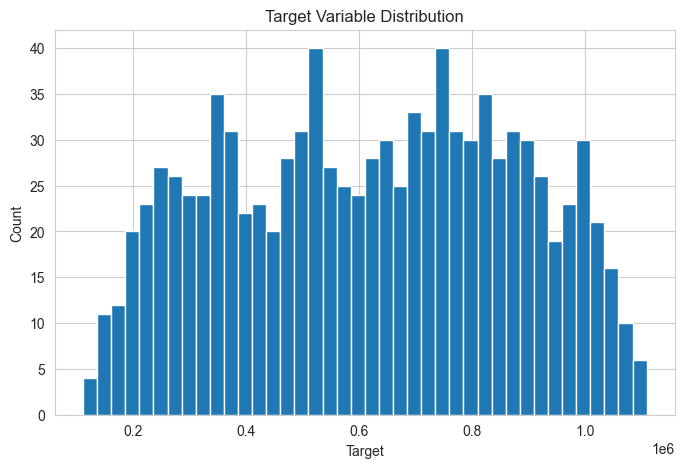

In [29]:
# Histogram for target variable (ALWAYS plot this first)
plt.figure(figsize=(8, 5))
df['House_Price'].hist(bins=40)
plt.title('Target Variable Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

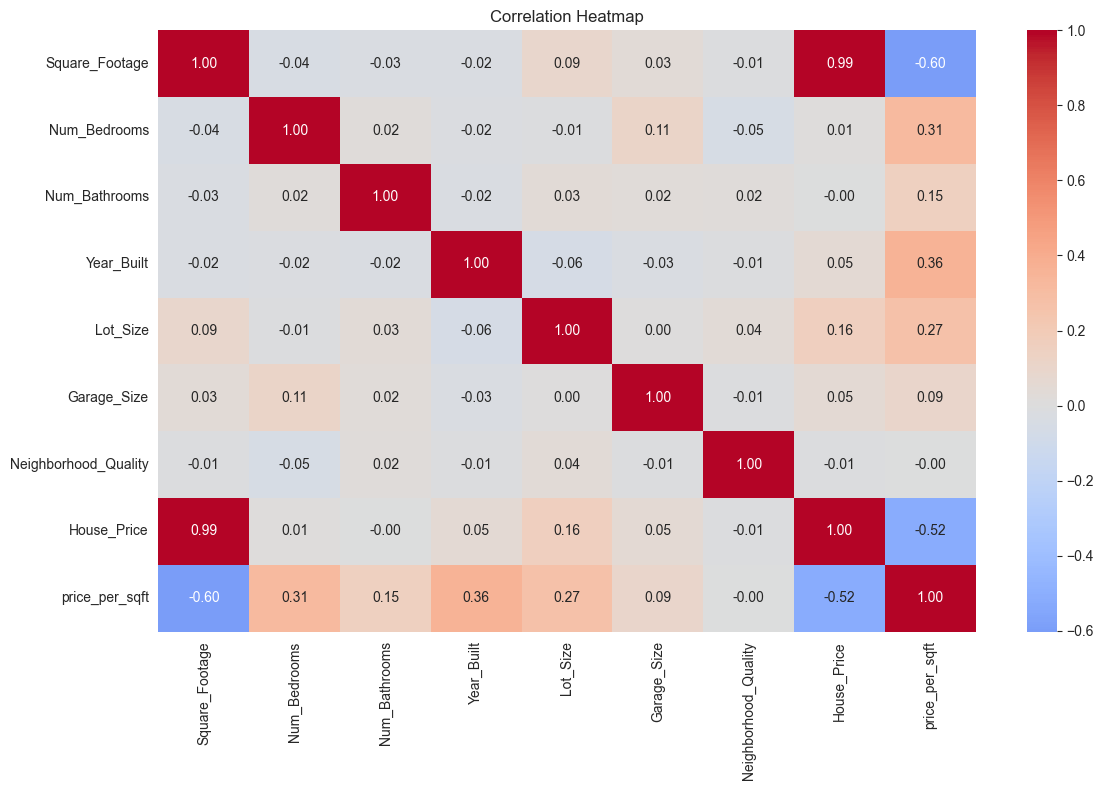

In [30]:
corr = df.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [31]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80-20 split (or 0.3 for 70-30)
    random_state=42      # reproducibility
    # NOTE: NO stratify for regression (stratify is for classification)
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (800, 8)
Test size:  (200, 8)


In [32]:
scaler = StandardScaler()

# CRITICAL ORDER: fit on train ONLY, then transform both
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_test_scaled  = scaler.transform(X_test)         # transform ONLY (no fit!)

In [33]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R²:  ", r2_score(y_test, y_pred_lr))

Linear Regression RMSE: 9666.297062096064
Linear Regression R²:   0.9985504350663911


In [34]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

In [35]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=7)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print("KNN RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("KNN R²:  ", r2_score(y_test, y_pred_knn))

KNN RMSE: 78537.06154511671
KNN R²:   0.9043099689482285


In [36]:
mae = mean_absolute_error(y_test, y_pred_lasso)
print(f"MAE: {mae:.4f}")

MAE: 7561.0826


In [37]:
# Store all predictions in a dict
models_preds = {
    'Linear Regression': y_pred_lr,
    # 'Ridge':             y_pred_ridge,
    'KNN':               y_pred_knn,
    # 'Decision Tree':     y_pred_dt,
    # 'SVR':               y_pred_svr,
    # 'Random Forest':   y_pred_rf,
}

# Build comparison table
results = []
for name, preds in models_preds.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)
    results.append({'Model': name, 'RMSE': round(rmse, 4),
                    'MAE': round(mae, 4), 'R²': round(r2, 4)})

results_df = pd.DataFrame(results).sort_values('RMSE')   # sort by RMSE ascending
print(results_df.to_string(index=False))

            Model       RMSE        MAE     R²
Linear Regression  9666.2971  7561.0381 0.9986
              KNN 78537.0615 64557.5790 0.9043


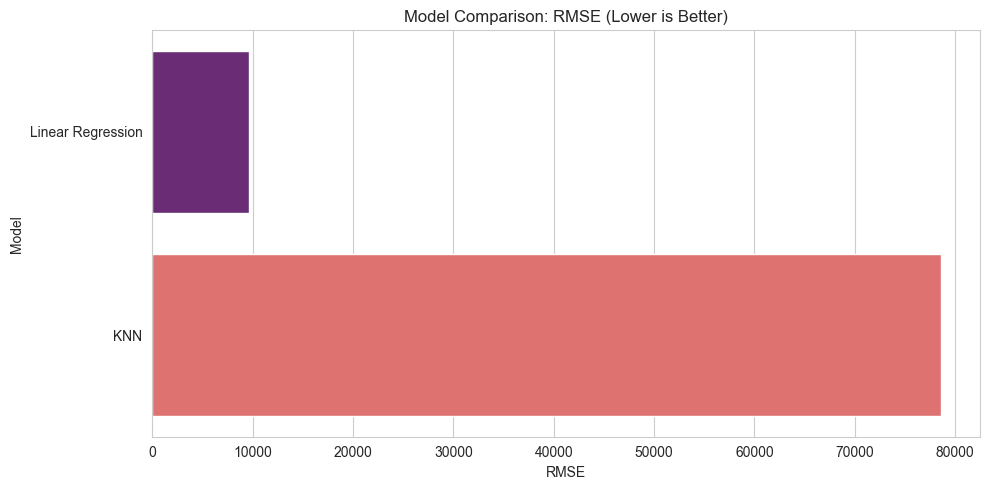

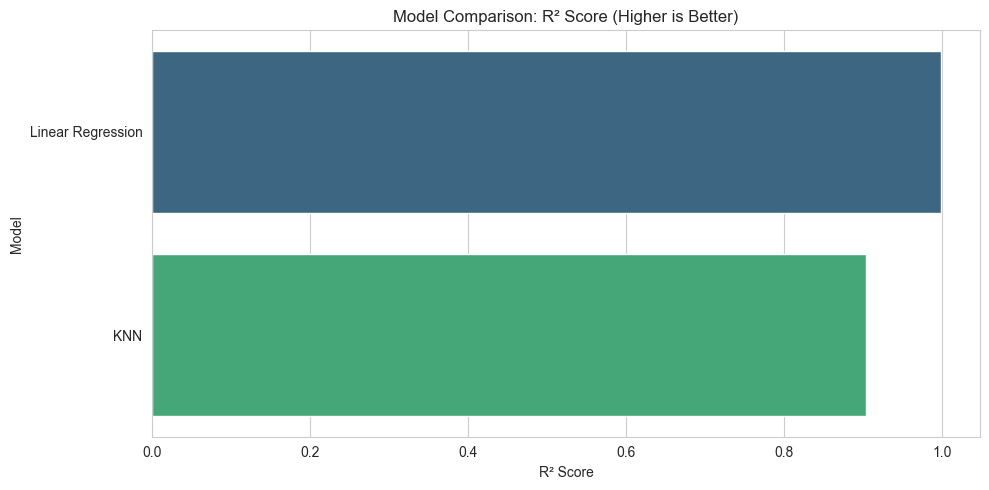

In [38]:
# RMSE bar chart (lower = better)
plt.figure(figsize=(10, 5))
sns.barplot(x='RMSE', y='Model', data=results_df, palette='magma')
plt.title('Model Comparison: RMSE (Lower is Better)')
plt.xlabel('RMSE')
plt.tight_layout()
plt.show()

# R² bar chart (higher = better)
plt.figure(figsize=(10, 5))
sns.barplot(x='R²', y='Model', data=results_df.sort_values('R²', ascending=False), palette='viridis')
plt.title('Model Comparison: R² Score (Higher is Better)')
plt.xlabel('R² Score')
plt.tight_layout()
plt.show()

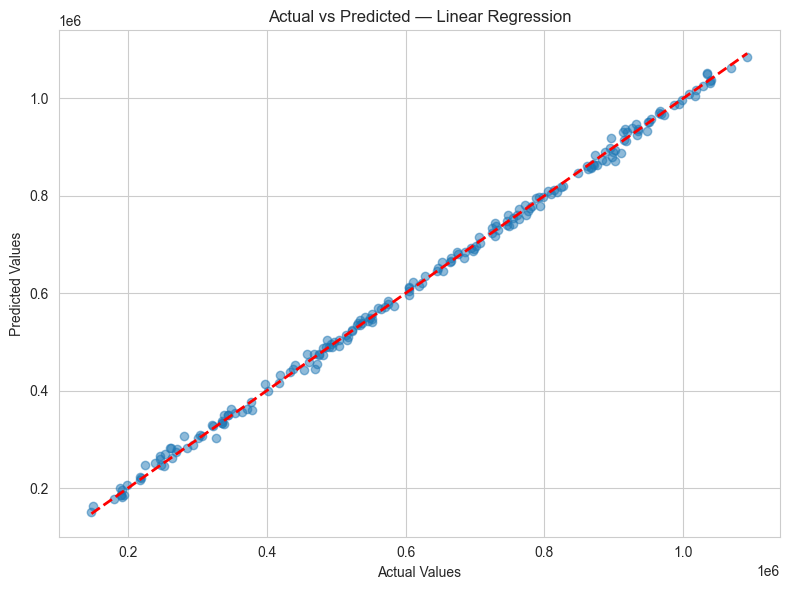

In [39]:
# Great visualization for regression — shows how well predictions match reality
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)   # perfect prediction line
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted — Linear Regression')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

baseline_model = RandomForestRegressor(random_state=42)
baseline_model.fit(X_train, y_train)
# cv=5 means 5-fold: splits data into 5 parts, trains 5 times
cv_scores = cross_val_score(baseline_model, X_train, y_train, cv=5,
                             scoring='neg_mean_squared_error')

# Convert to RMSE (scores are negative by convention)
rmse_scores = np.sqrt(-cv_scores)
print(f"CV RMSE scores: {rmse_scores}")
print(f"Mean CV RMSE:   {rmse_scores.mean():.4f}")
print(f"Std CV RMSE:    {rmse_scores.std():.4f}")



CV RMSE scores: [15335.56722301 12464.21275898 12293.94233888 14820.25837342
 12747.14020071]
Mean CV RMSE:   13532.2242
Std CV RMSE:    1280.7361


In [41]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor    # or Classifier

# Step 1: Define parameter grid (all combinations will be tried)
# param_grid = {
#     "fit_intercept": [True, False],
#     "positive": [True, False]
# }
param_grid = {
    'n_estimators':    [50, 100, 200],
    'max_depth':       [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
# Total combinations: 3 × 4 × 3 = 36 combos × 5 folds = 180 fits

# Step 2: Create GridSearchCV
grid_search = GridSearchCV(
    estimator  = RandomForestRegressor(),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'neg_mean_squared_error',   # for regression
    # scoring  = 'accuracy',                 # for classification
    n_jobs     = -1,     # use all CPU cores (faster)
    verbose    = 1       # shows progress
)

# Step 3: Fit (this trains ALL combinations)
grid_search.fit(X_train, y_train)

# Step 4: Get results
print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:  ", np.sqrt(-grid_search.best_score_))  # convert for RMSE

# Step 5: Get best model (already trained with best params)
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score:   13434.785025547782


In [42]:
# Get predictions from all 3 versions
y_pred_baseline = baseline_model.predict(X_test)
y_pred_grid     = best_model.predict(X_test)
# y_pred_random   = best_random_model.predict(X_test)

# Build comparison table
comparison = pd.DataFrame({
    'Model':    ['Baseline', 'Grid Search Tuned'],
    'RMSE':     [
        np.sqrt(mean_squared_error(y_test, y_pred_baseline)),
        np.sqrt(mean_squared_error(y_test, y_pred_grid)),
        # np.sqrt(mean_squared_error(y_test, y_pred_random))
    ],
    'R²':       [
        r2_score(y_test, y_pred_baseline),
        r2_score(y_test, y_pred_grid),
        # r2_score(y_test, y_pred_random)
    ]
})

print(comparison.to_string(index=False))

NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.